In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.pyplot as plt
from path_config import PathConfig
from sklearn.neighbors import kneighbors_graph
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
paths = PathConfig()

In [2]:
data = pd.read_csv(paths._processed_saha_olcum_dir / "dl_data_group_by_location.csv")
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

data = pd.read_csv(paths._processed_saha_olcum_dir / "5G_DataSet.csv")
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]


In [3]:
def latitude_to_meter(data):
    latitude = data["Latitude"]*111320
    return latitude

def longitude_to_meter(data):
    if isinstance(data["Latitude"],float):
        longitude = float(np.cos(np.radians(data["Latitude"]))*111320*(data["Longitude"]))
    else:
        longitude = np.cos(np.radians(data["Latitude"].astype(float)))*111320*(data["Longitude"].astype(float))
    return longitude

In [4]:
data["x"] = longitude_to_meter(data)
data["y"] = latitude_to_meter(data)

x = data["x"]
y = data["y"]

data = data.drop(columns=["Longitude", "Latitude","Time"])

In [5]:
n = 10
X = np.concatenate((np.array(x).reshape(1,-1), np.array(y).reshape(1,-1)))
X = X.T

knn_graph = kneighbors_graph(X, 50, include_self=False)
aggc = AgglomerativeClustering(n_clusters=n, linkage= "ward", connectivity = knn_graph).fit(X)

data["aggc_groups"] = aggc.labels_

cluster_centers_aggc = [(data[["x","y"]][data["aggc_groups"]==i]).mean() for i in set(aggc.labels_)]

cluster_centers_aggc_x = np.array(cluster_centers_aggc)[:,:1]
cluster_centers_aggc_y = np.array(cluster_centers_aggc)[:,1:]

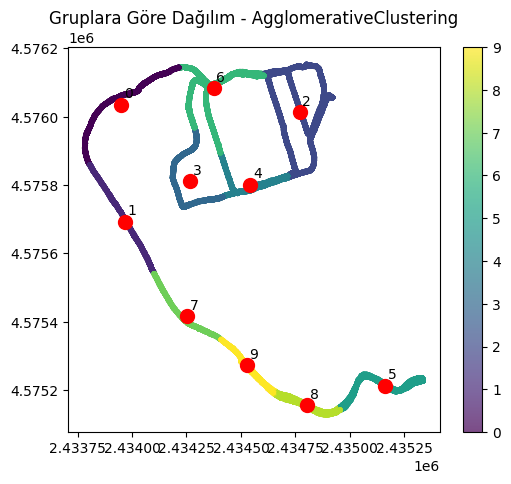

In [6]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    x,
    y,
    c=aggc.labels_,
    cmap="viridis",
    s=10,
    alpha=0.7
)

ax.scatter(
    cluster_centers_aggc_x,
    cluster_centers_aggc_y,
    s=100,
    c="red",
    
)

for i, (x_, y_) in enumerate(zip(cluster_centers_aggc_x, cluster_centers_aggc_y)):
    ax.annotate(str(i), (x_,y_), textcoords="offset points", xytext=(5, 5), ha='center')
    
ax.set_title("Gruplara Göre Dağılım - AgglomerativeClustering")

cbar = plt.colorbar(sc)

plt.show()

# Setting train-test datasets manually
aggc_train_test = {
    2:[0,1,3,5,7,8,9],
    4:[0,1,3,5,6,7,8],
    3:[0,1,2,4,5,7,9],
    6:[1,0,4,7,9,8,5],
    0:[2,3,4,7,9,8,6],
    1:[2,3,4,5,6,8,9],
    7:[0,2,3,4,6,8,9],
    9:[0,1,2,3,6,7,8],
    8:[0,1,2,4,5,6,7,9],
    5:[1,2,3,4,6,8]
}

aggc_train_test = {
    2:[3,0,1,7,9,8,5],
    4:[0,1,7,9,8,5],
    3:[2,1,7,9,8,5,0],
    6:[1,7,9,8,5],
    0:[2,3,4,7,9,8,5],
    1:[2,3,4,5,6,8,9],
    7:[0,2,3,4,5,8,6],
    9:[0,1,2,3,4,5,6],
    8:[1,2,3,4,6,7,0],
    5:[1,2,3,4,6,7,9,0]
}

In [13]:
drop_cols = ["aggc_groups","x","y"]

for i in aggc_train_test:
    train, test = data[[True if e in aggc_train_test[i] else False for e in data["aggc_groups"]]], data[data["aggc_groups"]==i]
    
    X_train, X_test = train.drop(columns=drop_cols), test.drop(columns=drop_cols)
    y_train, y_test = train[["x","y"]], test[["x","y"]]

    multioutput_regressor = MultiOutputRegressor(RandomForestRegressor(n_jobs=-1))
    
    multioutput_regressor.fit(X_train, y_train)

    y_pred = multioutput_regressor.predict(X_test)

    mean_euclidean_error = np.mean(np.sqrt(np.sum((y_test - y_pred)**2, axis=1)))
    
    print("Avg Euclidean Distance:", mean_euclidean_error)

    max_euclidean_error = np.max(np.sqrt(np.sum((y_test - y_pred)**2, axis=1)))
    print("Max Euclidean Distance:", max_euclidean_error)
    print("\n")

Avg Euclidean Distance: 559.7897289593569
Max Euclidean Distance: 797.7998749758668


Avg Euclidean Distance: 492.7579389614261
Max Euclidean Distance: 648.6207578230506


Avg Euclidean Distance: 506.3129515100031
Max Euclidean Distance: 587.0135646602614


Avg Euclidean Distance: 650.9146586741916
Max Euclidean Distance: 868.083717678737


Avg Euclidean Distance: 611.433036932693
Max Euclidean Distance: 962.4727484031174


Avg Euclidean Distance: 576.4438732176442
Max Euclidean Distance: 877.2649605010496


Avg Euclidean Distance: 553.9570589617715
Max Euclidean Distance: 745.9565858086256


Avg Euclidean Distance: 237.7212669840016
Max Euclidean Distance: 352.492314805432


Avg Euclidean Distance: 806.283808437636
Max Euclidean Distance: 1352.9335811859469


Avg Euclidean Distance: 833.0967189657052
Max Euclidean Distance: 1117.405315539769


